## 2 SIFT+HOG & SVM
This method implements a machine learning pipeline for image classification. Note that the complete processing pipeline are defined in the main function, which performs the following steps in sequence:


1. Import Necessary Libraries
2. Data Loading and Preprocessing
3. Feature Extraction (SIFT & HOG)
4. SVM Model Training
5. Model Prediction and Evaluation
6. Result Reporting and displaying

## 2.1 Import Necessary Libraries and Modules<br>

Libraries:
- NumPy: numerical operations and array handling
- OpenCV: image loading, color conversion, and preprocessing
- Matplotlib: visualisation (confusion matrix, AUC)
- scikit-learn: SVM classifier, metrics, and train/test utilities
- tqdm: progress bars for  image processing, feature extraction
- datetime/time: timestamping and performance measurement

Project Modules:
- extract_sift_features: SIFT descriptor extraction
- extract_hog_features: HOG feature extraction
- train_svm / evaluate_svm: SVM training and prediction
- read_images: dataset loading and preprocessing


In [ ]:
import numpy as np
import cv2
import time
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from datetime import datetime
from tqdm import tqdm
from datetime import datetime
from Model.machine_learning import extract_sift_features
from Model.machine_learning import extract_hog_features
from Model.machine_learning import train_svm, evaluate_svm
from Model.machine_learning import read_images
from sklearn.metrics import (accuracy_score, 
                            precision_score,
                            recall_score,
                            f1_score,
                            classification_report, 
                            confusion_matrix,
                            ConfusionMatrixDisplay,
                            roc_auc_score,
                            average_precision_score)

## 2.2 Data Downloading and Preprocessing
I. Data downloading<br>
Implemented in Download_image(). This function downloads the dataset, lists class names and image counts for train, test and valid.<br>The method returns the required six file paths for these image and corresponding label directories.

II. Data Preprocessing<br>
Implemented in read_images(image_path, label_path, apply_preprocess, output_rgb)<br>
- The function iterates through images in the given directory and reads corresponding YOLO-format labels to determine bounding box coordinates.<br>
- If appky_preprocess is set to true, it converts the cropped object to HSV, applies Gaussian blurring for smoothing, and returns the result(HSV or RGB).<br>
- The function outputs a list of (Class ID, Processed Image) tuples.

In [ ]:
def download_image():
    import kagglehub
    from pathlib import Path
    import yaml

    data_path = kagglehub.dataset_download("rupankarmajumdar/crop-pests-dataset")
    print(f"Data downloaded to: {data_path}")
    data_path = Path(data_path)

    yaml_path = data_path / 'data.yaml'
    with open(yaml_path, 'r') as file:
        yaml_config = yaml.safe_load(file)

    class_names = yaml_config['names']

    print("\nClass Names:")
    for i, class_name in enumerate(class_names, 1):
        print(f"    {i}. {class_name}")

    train_img_path = data_path / 'train' / 'images'
    train_lab_path = data_path / 'train' / 'labels'

    test_img_path = data_path / 'test' / 'images'
    test_lab_path = data_path / 'test' / 'labels'

    valid_img_path = data_path / 'valid' / 'images'
    valid_lab_path = data_path / 'valid' / 'labels'

    print(f"\nTrain image number: {len(list(train_img_path.glob('*.jpg')))}")
    print(f"Test image number: {len(list(test_img_path.glob('*.jpg')))}")
    print(f"Valid image number: {len(list(valid_img_path.glob('*.jpg')))}")

    return train_img_path, train_lab_path, test_img_path, test_lab_path, valid_img_path, valid_lab_path

## 2.3 Feature Extraction (SIFT & HOG)

Implemented in ectract_features(processed_img)<br>

1. Extracts SIFT descriptors with nfeatures = 150 to capture local keypoint information
2. Applies an HSV-based mask before computing HOG to help the descriptor focuses on the insect region
3. hstack the SIFT and masked HOG features to form a unified feature vector for each sample<br>

This function produces the concatenated feature matrix X and corresponding label vector Y

In [7]:
def extract_features(processed_img): 
    X = [] 
    Y = [] 
    for (id, img) in tqdm(processed_img, desc="Extracting features", unit="img"): 
        sift_descriptors, kps = extract_sift_features(img, 150)

        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV) 
        mask = cv2.inRange(hsv, (0, 70, 50), (180, 255, 255)) 
        masked = cv2.bitwise_and(img, img, mask=mask) 
        hog_descriptors = extract_hog_features(masked) 
        
        descriptors = np.hstack((sift_descriptors, hog_descriptors)) 
        X.append(descriptors) 
        Y.append(id) 

    return np.array(X), np.array(Y)

## 2.6 Model Evalution
Evalute the model's performance by comparing the predicted labels (pre_label) against the true labels (Y_test) using following metrics: 
- Accuracy
- Precision
- Recall
- F1-score
- AUC
- mAP
- confusion matrix

In [8]:
def evaluate_model(name, real_label, predicted_label, 
                   y_score=None, train_time=None, test_time=None):

    print(f"\n=== {name} Performance ===")
    acc = accuracy_score(real_label, predicted_label)
    prec = precision_score(real_label, predicted_label, average='macro', zero_division=0)
    rec = recall_score(real_label, predicted_label, average='macro', zero_division=0)
    f1 = f1_score(real_label, predicted_label, average='macro', zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    auc = None
    mAP = None
    if y_score is not None:
        try:
            auc = roc_auc_score(real_label, y_score, multi_class='ovr')
            print(f"AUC      : {auc:.4f}")
        except Exception as e:
            print(f"AUC could not be computed: {e}")

        try:
            mAP = average_precision_score(real_label, y_score, average='macro')
            print(f"mAP      : {mAP:.4f}")
        except Exception as e:
            print(f"mAP could not be computed: {e}")

    if train_time is not None:
        print(f"Training time: {train_time:.3f} s")
    if test_time is not None:
        print(f"Testing time : {test_time:.3f} s")

    print("\nClassification report:\n", 
          classification_report(real_label, predicted_label, zero_division=0))
    
    cm = confusion_matrix(real_label, predicted_label)

    print("ConfusionMatrix:")

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=np.unique(real_label)
    )
    cm_display.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "mAP": mAP,
        "train_time": train_time,
        "test_time": test_time,
    }

## 2.4 SVM Model Training
Training the Support Vector Machine (SVM) classifier (clf) on the training data (X,Y) and measuring the training time.

## 2.5 Model Prediction
Use the SVM from Section 2.4 to predict labels for the unseen test data (X_test) and obtain the raw decision scores (y_score).

Data downloaded to: /Users/raina/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2

Class Names:
    1. Ants
    2. Bees
    3. Beetles
    4. Caterpillars
    5. Earthworms
    6. Earwigs
    7. Grasshoppers
    8. Moths
    9. Slugs
    10. Snails
    11. Wasps
    12. Weevils

Train image number: 11502
Test image number: 546
Valid image number: 1095
Reading and preprocessing training images...


Reading images: 100%|██████████| 11502/11502 [01:08<00:00, 168.93img/s]


Extracting features from training set...


Extracting features: 100%|██████████| 7641/7641 [10:39<00:00, 11.96img/s]


7641Freature Extracted
SVM TRAINED


Extracting features: 100%|██████████| 689/689 [00:40<00:00, 16.82img/s]


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([146,  87,  12,  81,  43,  37,  57,  44,  12,  50,  58,  62]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([87, 44, 44, 93, 40, 73, 55, 47, 51, 50, 47, 58]))

=== SIFT+HOG & SVM Performance ===
Accuracy : 0.4194
Precision: 0.4033
Recall   : 0.4111
F1-score : 0.3906
AUC      : 0.8266
mAP      : 0.3375
Training time: 1411.892 s
Testing time : 238.713 s

Classification report:
               precision    recall  f1-score   support

           0       0.38      0.64      0.48        87
           1       0.23      0.45      0.31        44
           2       0.25      0.07      0.11        44
           3       0.47      0.41      0.44        93
           4       0.35      0.38      0.36        40
           5       0.35      0.18      0.24        73
           6       0.39      0.40      0.39        55
           7       0.68      0.64      0.66        47
           8       0.17      0.04      0.06        

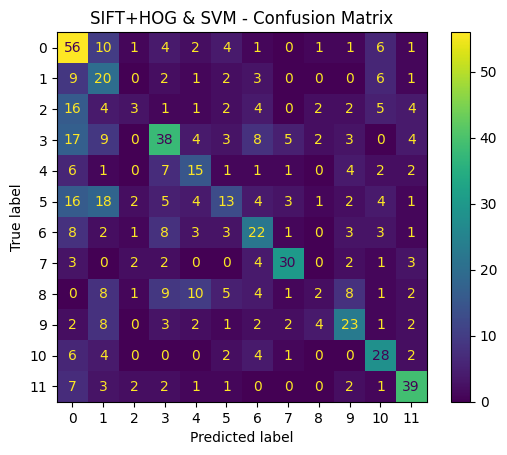

In [ ]:
if __name__ == "__main__":
    image_path, label_path, test_image_path, test_label_path, valid_image_path, valid_label_path = download_image()

    print("Reading and preprocessing training images...")
    processed_img = read_images(image_path, label_path, apply_preprocess=True, output_rgb=True)

    labels = np.array([cls for cls, _ in processed_img])

    # Use 50% of dataset for convenience
    _, sampled_img, _, _ = train_test_split(
        processed_img, labels,
        test_size=0.5,
        stratify=labels,
        random_state=42
    )

    print("Extracting features from training set...")
    X, Y = extract_features(sampled_img)

    print(f"{len(X)}Freature Extracted")

    train_start = time.perf_counter()
    clf = train_svm(X, Y, tune=False)
    train_time = time.perf_counter() - train_start

    print("SVM TRAINED")

    test_start = time.perf_counter()
    processed_test_img = read_images(test_image_path, test_label_path, apply_preprocess=True, output_rgb=True)

    X_test, Y_test = extract_features(processed_test_img)

    pre_label = evaluate_svm(clf, X_test)
    test_time = time.perf_counter() - test_start

    y_score = None
    try:
        y_score = clf.decision_function(X_test)
        y_score = np.exp(y_score) / np.sum(np.exp(y_score), axis=1, keepdims=True)
    except Exception as e:
        print(f"Warning: could not obtain scores for AUC/mAP ({e})")
        y_score = None

    print(np.unique(pre_label, return_counts=True))
    print(np.unique(Y_test, return_counts=True))

    with open('report', 'a+') as file:
        now = datetime.now()
        file.write(f"{now.strftime('%Y-%m-%d %H:%M:%S')} {accuracy_score(pre_label, Y_test):.4f}\n")

    metrics = evaluate_model(
        "SIFT+HOG & SVM",
        Y_test,
        pre_label,
        y_score=y_score,
        train_time=train_time,
        test_time=test_time
    )
